<a href="https://colab.research.google.com/github/Mru-preeti/Image_Generation/blob/main/Unconditional_Image_gen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
import os

print(os.listdir("/content"))

['.config', 'diffusion.py', 'model.py', 'train.py', 'dataset.py', 'sample_data']


In [5]:
from dataset import get_dataloader
from diffusion import Diffusion
from model import UNet

print("All imports successful! ✅")

All imports successful! ✅


In [6]:
dataloader = get_dataloader(batch_size=128)

images, labels = next(iter(dataloader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Min:", images.min().item())
print("Max:", images.max().item())

100%|██████████| 170M/170M [51:57<00:00, 54.7kB/s]


Images: torch.Size([128, 3, 32, 32])
Labels: torch.Size([128])
Min: -1.0
Max: 1.0


In [7]:
import torch
from model import UNet
from diffusion import Diffusion

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

# Load one batch
dataloader = get_dataloader(batch_size=128)
images, labels = next(iter(dataloader))

images = images.to(device)

# Create diffusion
diffusion = Diffusion(
    noise_steps=1000,
    img_size=32,
    device=device
)

# Pick timesteps
t = diffusion.sample_timesteps(images.shape[0])

# Add noise
noisy_images, noise = diffusion.noise_images(images, t)

# Create U-Net
model = UNet().to(device)

# Predict noise
predicted_noise = model(noisy_images, t)

print("Images:", images.shape)
print("Noisy images:", noisy_images.shape)
print("Predicted noise:", predicted_noise.shape)

Device: cuda
Images: torch.Size([128, 3, 32, 32])
Noisy images: torch.Size([128, 3, 32, 32])
Predicted noise: torch.Size([128, 3, 32, 32])


In [8]:
!python train.py

Using device: cuda

Epoch 1/50
100% 391/391 [00:28<00:00, 13.90it/s, loss=0.0823]
Saved checkpoint: epoch 1

Epoch 2/50
100% 391/391 [00:27<00:00, 14.26it/s, loss=0.0844]
Saved checkpoint: epoch 2

Epoch 3/50
100% 391/391 [00:27<00:00, 14.26it/s, loss=0.0985]
Saved checkpoint: epoch 3

Epoch 4/50
100% 391/391 [00:26<00:00, 15.03it/s, loss=0.0618]
Saved checkpoint: epoch 4

Epoch 5/50
100% 391/391 [00:26<00:00, 14.75it/s, loss=0.0908]
Saved checkpoint: epoch 5

Epoch 6/50
100% 391/391 [00:26<00:00, 14.49it/s, loss=0.053]
Saved checkpoint: epoch 6

Epoch 7/50
100% 391/391 [00:26<00:00, 14.83it/s, loss=0.0801]
Saved checkpoint: epoch 7

Epoch 8/50
100% 391/391 [00:26<00:00, 14.99it/s, loss=0.0745]
Saved checkpoint: epoch 8

Epoch 9/50
100% 391/391 [00:26<00:00, 14.99it/s, loss=0.086]
Saved checkpoint: epoch 9

Epoch 10/50
100% 391/391 [00:26<00:00, 14.95it/s, loss=0.0536]
Saved checkpoint: epoch 10

Epoch 11/50
100% 391/391 [00:26<00:00, 15.01it/s, loss=0.0416]
Saved checkpoint: epoch 11


Using device: cuda
Starting from noise...
Denoising complete!


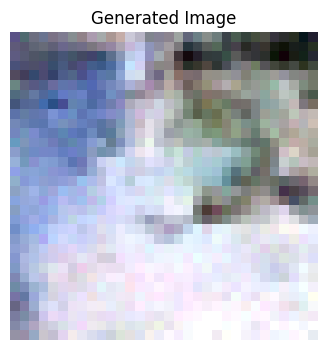

In [9]:
import torch
import matplotlib.pyplot as plt

from model import UNet
from diffusion import Diffusion

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load trained model
model = UNet().to(device)

model.load_state_dict(
    torch.load(
        "./outputs/ddpm_epoch_50.pth",
        map_location=device
    )
)

model.eval()

# Diffusion setup
diffusion = Diffusion(
    noise_steps=1000,
    img_size=32,
    device=device
)

# Start from pure random noise
x = torch.randn(
    1, 3, 32, 32,
    device=device
)

print("Starting from noise...")

# Reverse diffusion
with torch.no_grad():

    for i in range(999, 0, -1):

        t = torch.tensor(
            [i],
            device=device
        )

        predicted_noise = model(x, t)

        beta = diffusion.beta[t][:, None, None, None]
        alpha = diffusion.alpha[t][:, None, None, None]
        alpha_hat = diffusion.alpha_hat[t][:, None, None, None]

        if i > 1:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha)
        ) * (
            x
            - ((1 - alpha) / torch.sqrt(1 - alpha_hat))
            * predicted_noise
        ) + torch.sqrt(beta) * noise

print("Denoising complete!")

# Convert [-1, 1] → [0, 1]
x = (x.clamp(-1, 1) + 1) / 2

# Convert CHW → HWC
image = x[0].permute(1, 2, 0)

# Display
plt.figure(figsize=(4, 4))
plt.imshow(image.cpu().numpy())
plt.axis("off")
plt.title("Generated Image")
plt.show()